In [10]:
import numpy as np
import pandas as pd
df = pd.read_csv('train.csv', encoding = 'latin1')
df.head()
df.info()
df.describe()


<class 'pandas.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   str    
 2   Order Date     9800 non-null   str    
 3   Ship Date      9800 non-null   str    
 4   Ship Mode      9800 non-null   str    
 5   Customer ID    9800 non-null   str    
 6   Customer Name  9800 non-null   str    
 7   Segment        9800 non-null   str    
 8   Country        9800 non-null   str    
 9   City           9800 non-null   str    
 10  State          9800 non-null   str    
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   str    
 13  Product ID     9800 non-null   str    
 14  Category       9800 non-null   str    
 15  Sub-Category   9800 non-null   str    
 16  Product Name   9800 non-null   str    
 17  Sales          9800 non-null   float64
dtypes: float64(2), int6

,Row ID,Postal Code,Sales
count,9800.000000,9789.000000,9800.000000
mean,4900.500000,55273.322403,230.769059
std,2829.160653,32041.223413,626.651875
min,1.000000,1040.000000,0.444000
25%,2450.750000,23223.000000,17.248000
50%,4900.500000,58103.000000,54.490000
75%,7350.250000,90008.000000,210.605000
max,9800.000000,99301.000000,22638.480000


In [3]:
df['Order Date'] = pd.to_datetime(df['Order Date'], format='%d/%m/%Y')
df['Ship Date'] = pd.to_datetime(df['Ship Date'], format='%d/%m/%Y')
df['Shipping_Delay_Days'] = (df['Ship Date'] - df['Order Date']).dt.days

In [6]:
model_df = df[['Region', 'Segment', 'Ship Mode', 'Sales', 'Shipping_Delay_Days', 'Category']].dropna()
model_df.shape
model_df['Category'].value_counts()
encoded_df = pd.get_dummies(model_df, columns=['Region', 'Segment', 'Ship Mode'], drop_first=True)
encoded_df.head()

,Sales,Shipping_Delay_Days,Category,Region_East,Region_South,Region_West,Segment_Corporate,Segment_Home Office,Ship Mode_Same Day,Ship Mode_Second Class,Ship Mode_Standard Class
0,261.9600,3,Furniture,False,True,False,False,False,False,True,False
1,731.9400,3,Furniture,False,True,False,False,False,False,True,False
2,14.6200,4,Office Supplies,False,False,True,True,False,False,True,False
3,957.5775,7,Furniture,False,True,False,False,False,False,False,True
4,22.3680,7,Office Supplies,False,True,False,False,False,False,False,True


In [11]:
class StandardScaler:
    def fit_transform(self, data):
        data = np.asarray(data, dtype=float)
        self.mean_ = data.mean(axis=0)
        self.scale_ = data.std(axis=0)
        self.scale_[self.scale_ == 0] = 1
        return (data - self.mean_) / self.scale_

scaler = StandardScaler()
encoded_df[['Sales', 'Shipping_Delay_Days']] = scaler.fit_transform(encoded_df[['Sales', 'Shipping_Delay_Days']])
encoded_df.head()

,Sales,Shipping_Delay_Days,Category,Region_East,Region_South,Region_West,Segment_Corporate,Segment_Home Office,Ship Mode_Same Day,Ship Mode_Second Class,Ship Mode_Standard Class
0,0.049776,-0.549362,Furniture,False,True,False,False,False,False,True,False
1,0.799801,-0.549362,Furniture,False,True,False,False,False,False,True,False
2,-0.344944,0.022222,Office Supplies,False,False,True,True,False,False,True,False
3,1.159887,1.736974,Furniture,False,True,False,False,False,False,False,True
4,-0.332580,1.736974,Office Supplies,False,True,False,False,False,False,False,True


In [12]:
np.random.seed(42)
shuffled_indices = np.random.permutation(len(encoded_df))
test_size = int(len(encoded_df) * 0.2)

test_indices = shuffled_indices[:test_size]
train_indices = shuffled_indices[test_size:]

feature_cols = [col for col in encoded_df.columns if col != 'Category']

X_train = encoded_df.iloc[train_indices][feature_cols].values.astype(float)
y_train = encoded_df.iloc[train_indices]['Category'].values

X_test = encoded_df.iloc[test_indices][feature_cols].values.astype(float)
y_test = encoded_df.iloc[test_indices]['Category'].values

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)
print("Train class distribution:")
print(pd.Series(y_train).value_counts())

Train size: (7840, 10)
Test size: (1960, 10)
Train class distribution:
Office Supplies    4718
Furniture          1673
Technology         1449
Name: count, dtype: int64


In [13]:
def knn_predict(X_train, y_train, X_test, k=5):
    predictions = []
    for test_point in X_test:
        # Compute distance from this test point to every training point
        distances = np.linalg.norm(X_train - test_point, axis=1)
        # Get indices of the k nearest neighbors
        nearest_indices = np.argsort(distances)[:k]
        nearest_labels = y_train[nearest_indices]
        # Majority vote
        values, counts = np.unique(nearest_labels, return_counts=True)
        predictions.append(values[np.argmax(counts)])
    return np.array(predictions)

# Test on a small subset first (KNN is slow on large data since it compares every point)
y_pred_sample = knn_predict(X_train, y_train, X_test[:50], k=5)
print(y_pred_sample[:10])
print(y_test[:10])

['Office Supplies' 'Office Supplies' 'Office Supplies' 'Office Supplies'
 'Office Supplies' 'Furniture' 'Office Supplies' 'Office Supplies'
 'Technology' 'Office Supplies']
<StringArray>
[      'Furniture', 'Office Supplies',      'Technology', 'Office Supplies',
 'Office Supplies', 'Office Supplies', 'Office Supplies', 'Office Supplies',
 'Office Supplies', 'Office Supplies']
Length: 10, dtype: str


In [14]:
sample_actual = y_test[:10]
sample_pred = y_pred_sample[:10]
accuracy_sample = np.mean(sample_pred == sample_actual)
print("Sample accuracy (first 10):", accuracy_sample)

Sample accuracy (first 10): 0.6


In [17]:
import time
start = time.time()
y_pred_300 = knn_predict(X_train, y_train, X_test[:300], k=5)
end = time.time()
accuracy_300 = np.mean(y_pred_300 == y_test[:300])
accuracy_full=np.mean(y_pred_full == y_test)
print("Accuracy on 300-sample test set:", accuracy_300)
print("Time taken:", round(end - start, 2), "seconds")
print("Accuracy on full test set:" , accuracy_full)
print("Time taken:",round(end - start, 2), "seconds")

Accuracy on 300-sample test set: 0.5733333333333334
Time taken: 0.36 seconds
Accuracy on full test set: 0.5821428571428572
Time taken: 0.36 seconds


In [18]:
labels = ['Furniture', 'Office Supplies', 'Technology']

def confusion_matrix_manual(y_true, y_pred, labels):
    matrix = np.zeros((len(labels), len(labels)), dtype=int)
    label_to_idx = {label: i for i, label in enumerate(labels)}
    for actual, pred in zip(y_true, y_pred):
        matrix[label_to_idx[actual]][label_to_idx[pred]] += 1
    return matrix

cm = confusion_matrix_manual(y_test, y_pred_full, labels)
cm_df = pd.DataFrame(cm, index=[f"Actual {l}" for l in labels], columns=[f"Predicted {l}" for l in labels])
print(cm_df)

                        Predicted Furniture  Predicted Office Supplies  \
Actual Furniture                        130                        222   
Actual Office Supplies                  168                        959   
Actual Technology                       125                        187   

                        Predicted Technology  
Actual Furniture                          53  
Actual Office Supplies                    64  
Actual Technology                         52  


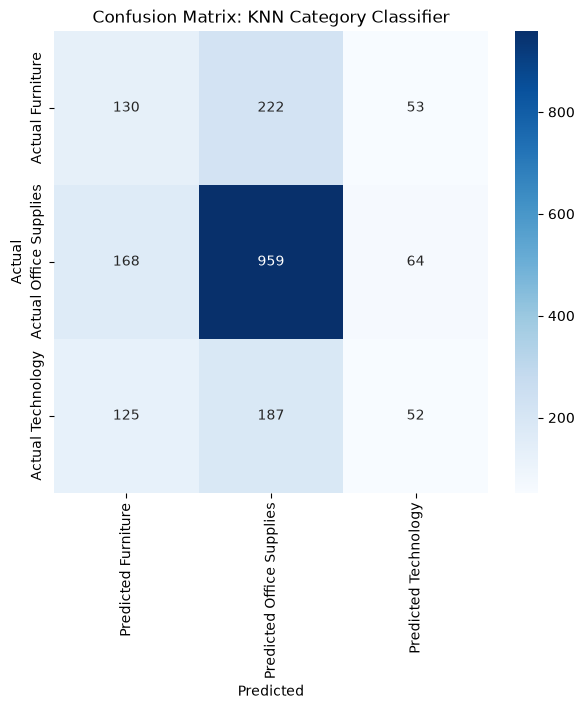

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7,6))
sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix: KNN Category Classifier')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

In [20]:
def precision_recall_f1(cm, labels):
    results = []
    for i, label in enumerate(labels):
        tp = cm[i][i]
        fp = cm[:, i].sum() - tp
        fn = cm[i, :].sum() - tp
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0
        f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
        results.append({'Class': label, 'Precision': round(precision, 3), 'Recall': round(recall, 3), 'F1': round(f1, 3)})
    return pd.DataFrame(results)

metrics_df = precision_recall_f1(cm, labels)
print(metrics_df)

             Class  Precision  Recall     F1
0        Furniture      0.307   0.321  0.314
1  Office Supplies      0.701   0.805  0.750
2       Technology      0.308   0.143  0.195


In [21]:
macro_f1 = metrics_df['F1'].mean()
print("Macro F1:", round(macro_f1, 3))

Macro F1: 0.42


In [22]:
def cross_validate_knn(X, y, k_folds=5, k_neighbors=5):
    np.random.seed(42)
    indices = np.random.permutation(len(X))
    fold_size = len(X) // k_folds
    accuracies = []
    
    for fold in range(k_folds):
        start = fold * fold_size
        end = start + fold_size if fold < k_folds - 1 else len(X)
        
        test_idx = indices[start:end]
        train_idx = np.concatenate([indices[:start], indices[end:]])
        
        X_train_fold, y_train_fold = X[train_idx], y[train_idx]
        X_test_fold, y_test_fold = X[test_idx], y[test_idx]
        
        preds = knn_predict(X_train_fold, y_train_fold, X_test_fold, k=k_neighbors)
        acc = np.mean(preds == y_test_fold)
        accuracies.append(acc)
        print(f"Fold {fold+1} accuracy: {acc:.4f}")
    
    print(f"\nMean CV accuracy: {np.mean(accuracies):.4f}")
    print(f"Std deviation: {np.std(accuracies):.4f}")
    return accuracies

# Use the full encoded feature matrix (X) and labels (y) combined, not just train split
X_full = encoded_df[feature_cols].values.astype(float)
y_full = encoded_df['Category'].values

cv_scores = cross_validate_knn(X_full, y_full, k_folds=5, k_neighbors=5)

Fold 1 accuracy: 0.5821
Fold 2 accuracy: 0.5837
Fold 3 accuracy: 0.5791
Fold 4 accuracy: 0.5745
Fold 5 accuracy: 0.5786

Mean CV accuracy: 0.5796
Std deviation: 0.0032


In [25]:
for k in [3, 5, 7, 9, 11,13,15,21,25,27]:
    preds = knn_predict(X_train, y_train, X_test, k=k)
    acc = np.mean(preds == y_test)
    print(f"K={k}, Accuracy={acc:.4f}")

K=3, Accuracy=0.5505
K=5, Accuracy=0.5821
K=7, Accuracy=0.5959
K=9, Accuracy=0.5964
K=11, Accuracy=0.6087
K=13, Accuracy=0.6066
K=15, Accuracy=0.6168
K=21, Accuracy=0.6163
K=25, Accuracy=0.6194
K=27, Accuracy=0.6219


In [26]:
preds_k11 = knn_predict(X_train, y_train, X_test, k=11)
cm_k11 = confusion_matrix_manual(y_test, preds_k11, labels)
metrics_k11 = precision_recall_f1(cm_k11, labels)
print(metrics_k11)
print("Macro F1 at K=11:", round(metrics_k11['F1'].mean(), 3))

             Class  Precision  Recall     F1
0        Furniture      0.352   0.286  0.316
1  Office Supplies      0.694   0.855  0.766
2       Technology      0.362   0.162  0.224
Macro F1 at K=11: 0.435
